<a href="https://colab.research.google.com/github/AndrijaM06/ml-product-category-prediction/blob/main/product_category_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predikcija kategorije proizvoda na osnovu naslova

Ova sveska sadrži kompletnu analizu, čišćenje podataka, inženjering karakteristika,
treniranje i evaluaciju modela za automatsku klasifikaciju proizvoda po kategoriji,
na osnovu naziva proizvoda (Product Title).

## 1. Učitavanje i osnovni pregled podataka

In [36]:
import pandas as pd

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/AndrijaM06/ml-product-category-prediction/main/data/products.csv"
df = pd.read_csv(url)

# Print shape
print("Dataset shape (rows, columns):", df.shape)

# Show first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Show column data types and non-null counts
print("\nDataset info:")
df.info()

Dataset shape (rows, columns): (35311, 8)

First 5 rows:


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


## 2. Čišćenje naziva kolona

Primeto sam da nazivi kolona sadrže suvišne razmake

Standardizujemo ih pre dalje analize

In [37]:
print("Original columns:", df.columns.tolist())

df.columns = [c.strip() for c in df.columns]

print("Cleaned columns:", df.columns.tolist())

Original columns: ['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']
Cleaned columns: ['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


## 3. Provera nedostajućih vrednosti

Pre nego što bilo šta modelujemo, proveravamo ima li praznih vrednosti i gde se nalaze.

In [38]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64


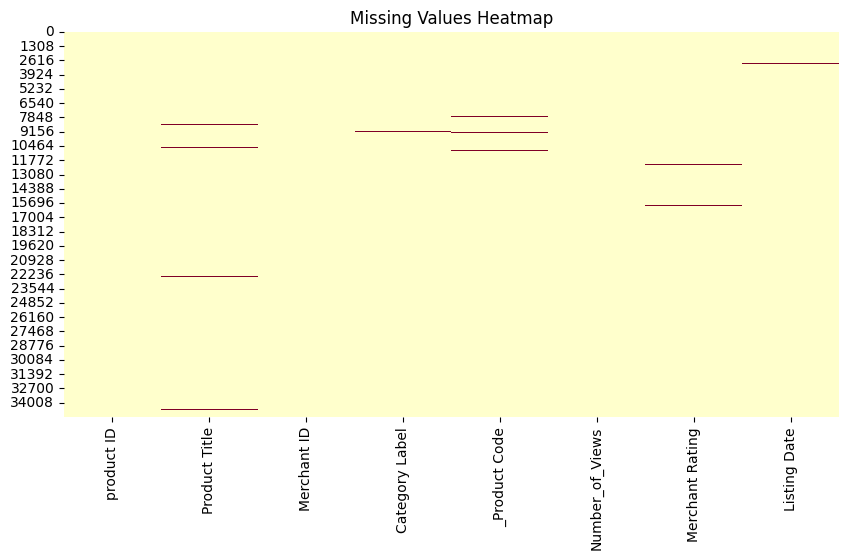

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

## 4. Analiza ciljne kolone: Category Label

Kolona `Category Label` predstavlja ciljnu vrednost koju model treba da predviđa.
Proveravamo koje sve vrednosti postoje i da li su konzistentne.

In [40]:
category_counts = df['Category Label'].value_counts()

print("Category distribution (counts):")
print(category_counts)

Category distribution (counts):
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


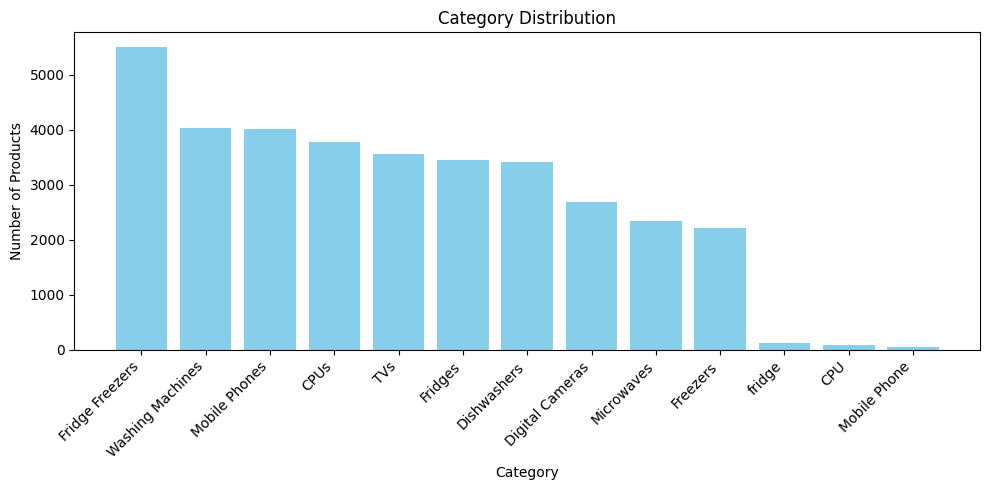

In [41]:
plt.figure(figsize=(10, 5))
plt.bar(category_counts.index, category_counts.values, color='skyblue')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Zapažanja iz EDA faze

- Dataset sadrži **35.311** redova i **8** kolona.
- Kolone `Product Title`, `Category Label`, `_Product Code`, `Number_of_Views` i
  `Merchant Rating` imaju nedostajuće vrednosti.
- Kolona `Category Label` sadrži **nekonzistentne, duplirane vrednosti** za iste
  kategorije, npr.:
  - `Fridges` i `fridge`
  - `CPUs` i `CPU`
  - `Mobile Phones` i `Mobile Phone`
- Ove vrednosti moramo standardizovati pre treniranja modela, jer bi ih model
  inače tretirao kao različite klase.

## 5. Čišćenje i standardizacija podataka

Sada uklanjamo nedostajuće vrednosti i standardizujemo tekstualne kolone.

### 5.1. Uklanjanje redova bez naslova ili bez kategorije

Kolone `Product Title` i `Category Label` su nam ključne (ulaz i ciljna vrednost),
pa redovi bez njih ne mogu da se koriste za treniranje.

In [42]:
rows_before = len(df)

df = df.dropna(subset=["Product Title", "Category Label"])

rows_after = len(df)

print(f"Number of rows before: {rows_before}")
print(f"Number of rows after: {rows_after}")
print(f"Number of removed rows: {rows_before - rows_after}")

Number of rows before: 35311
Number of rows after: 35096
Number of removed rows: 215


### 5.2. Standardizacija naslova proizvoda

Prevodimo sve naslove u mala slova i uklanjamo suvišne razmake, kako bi tekst
bio konzistentan pre vektorizacije.

In [43]:
df["Product Title"] = df["Product Title"].astype(str).str.lower().str.strip()

print(df["Product Title"].head(10))

0                      apple iphone 8 plus 64gb silver
1                  apple iphone 8 plus 64 gb spacegrau
2    apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...
3                  apple iphone 8 plus 64gb space grey
4    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
5    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
6                 apple iphone 8 plus 64 gb space grey
7                  apple iphone 8 plus 64gb space grey
8                  apple iphone 8 plus 64gb space grey
9                  apple iphone 8 plus 64gb space grey
Name: Product Title, dtype: object


### 5.3. Standardizacija kolone Category Label

Kao što smo primetili u EDA fazi, kolona `Category Label` ima duplirane vrednosti
zbog različitog zapisa (velika/mala slova, jednina/množina). Mapiramo ih na
jedinstven, kanonski naziv kategorije.

In [44]:
df["Category Label"] = df["Category Label"].astype(str).str.strip()

category_map = {
    "fridge": "Fridges",
    "fridges": "Fridges",
    "fridge freezers": "Fridge Freezers",
    "cpu": "CPUs",
    "cpus": "CPUs",
    "mobile phone": "Mobile Phones",
    "mobile phones": "Mobile Phones",
    "tv": "TVs",
    "tvs": "TVs",
    "digital camera": "Digital Cameras",
    "digital cameras": "Digital Cameras",
    "microwave": "Microwaves",
    "microwaves": "Microwaves",
    "dishwasher": "Dishwashers",
    "dishwashers": "Dishwashers",
    "washing machine": "Washing Machines",
    "washing machines": "Washing Machines",
    "freezer": "Freezers",
    "freezers": "Freezers",
}

df["Category Label"] = (
    df["Category Label"].str.lower().map(category_map).fillna(df["Category Label"])
)

# Convert column type to 'category'
df["Category Label"] = df["Category Label"].astype("category")

print("Unique categories after cleaning:")
print(df["Category Label"].value_counts())

Unique categories after cleaning:
Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: int64


### 5.4. Uklanjanje dupliranih naslova proizvoda

Isti proizvod se ponekad pojavljuje više puta u skupu podataka. Uklanjamo duplikate
naslova kako model ne bi bio pristrasan ka često ponovljenim proizvodima.

In [45]:
rows_before = len(df)

df = df.drop_duplicates(subset=["Product Title"])

rows_after = len(df)

print(f"Number of rows before removing duplicates: {rows_before}")
print(f"Number of rows after removing duplicates: {rows_after}")
print(f"Number of removed duplicate rows: {rows_before - rows_after}")

Number of rows before removing duplicates: 35096
Number of rows after removing duplicates: 30824
Number of removed duplicate rows: 4272


### 5.5. Provera stanja nakon čišćenja

In [46]:
print("Final dataset shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nFinal category distribution:")
print(df["Category Label"].value_counts())

Final dataset shape: (30824, 8)

Missing values per column:
product ID           0
Product Title        0
Merchant ID          0
Category Label       0
_Product Code       85
Number_of_Views     10
Merchant Rating    154
Listing Date        54
dtype: int64

Final category distribution:
Category Label
Fridge Freezers     4809
Mobile Phones       3662
Washing Machines    3403
TVs                 3275
Fridges             3188
CPUs                3043
Dishwashers         3042
Digital Cameras     2405
Microwaves          2094
Freezers            1903
Name: count, dtype: int64


## Zapažanja iz faze čišćenja

- Uklonjeni su redovi bez naslova ili bez kategorije.
- Standardizovan je tekst naslova (mala slova, bez viška razmaka).
- Kategorije su svedene na jedinstven, kanonski oblik (npr. `fridge` → `Fridges`).
- Uklonjeni su duplirani naslovi proizvoda.
- Dataset je sada čist i konzistentan, spreman za inženjering karakteristika.

## 6. Inženjering karakteristika

Sada iz naslova proizvoda izvlačimo dodatne karakteristike koje mogu pomoći
modelu da preciznije predviđa kategoriju

### 6.1. Dužina naslova (broj karaktera)

In [47]:
df["title_length"] = df["Product Title"].str.len()

print(df[["Product Title", "title_length"]].head(10))
print("\nTitle length summary:")
print(df["title_length"].describe())

                                        Product Title  title_length
0                     apple iphone 8 plus 64gb silver            31
1                 apple iphone 8 plus 64 gb spacegrau            35
2   apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            70
3                 apple iphone 8 plus 64gb space grey            35
4   apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            54
6                apple iphone 8 plus 64 gb space grey            36
10  apple iphone 8 plus 5.5 single sim 4g 64gb silver            49
11    sim free iphone 8 plus 64gb by apple space grey            47
12           apple iphone 8 plus 64gb gold smartphone            40
13    apple iphone 8 plus 5.5 single sim 4g 64gb grey            47

Title length summary:
count    30824.000000
mean        52.760349
std         22.621977
min          5.000000
25%         38.000000
50%         51.000000
75%         65.000000
max        200.000000
Name: title_length, dtype: float64


### 6.2. Broj reči u naslovu

In [48]:
df["word_count"] = df["Product Title"].str.split().str.len()

print(df[["Product Title", "word_count"]].head(10))
print("\nWord count summary:")
print(df["word_count"].describe())

                                        Product Title  word_count
0                     apple iphone 8 plus 64gb silver           6
1                 apple iphone 8 plus 64 gb spacegrau           7
2   apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...          13
3                 apple iphone 8 plus 64gb space grey           7
4   apple iphone 8 plus gold 5.5 64gb 4g unlocked ...          11
6                apple iphone 8 plus 64 gb space grey           8
10  apple iphone 8 plus 5.5 single sim 4g 64gb silver          10
11    sim free iphone 8 plus 64gb by apple space grey          10
12           apple iphone 8 plus 64gb gold smartphone           7
13    apple iphone 8 plus 5.5 single sim 4g 64gb grey          10

Word count summary:
count    30824.000000
mean         8.649461
std          4.215697
min          1.000000
25%          6.000000
50%          8.000000
75%         11.000000
max         37.000000
Name: word_count, dtype: float64


### 6.3. Da li naslov sadrži brojeve

Mnogi proizvodi u nazivu imaju kapacitet, model ili godinu (npr. "64gb", "2023"),
pa je prisustvo brojeva potencijalno koristan signal za kategoriju.

In [49]:
df["has_digit"] = df["Product Title"].str.contains(r"\d", regex=True).astype(int)

print(df[["Product Title", "has_digit"]].head(10))
print("\nShare of titles containing digits:")
print(df["has_digit"].value_counts(normalize=True))

                                        Product Title  has_digit
0                     apple iphone 8 plus 64gb silver          1
1                 apple iphone 8 plus 64 gb spacegrau          1
2   apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...          1
3                 apple iphone 8 plus 64gb space grey          1
4   apple iphone 8 plus gold 5.5 64gb 4g unlocked ...          1
6                apple iphone 8 plus 64 gb space grey          1
10  apple iphone 8 plus 5.5 single sim 4g 64gb silver          1
11    sim free iphone 8 plus 64gb by apple space grey          1
12           apple iphone 8 plus 64gb gold smartphone          1
13    apple iphone 8 plus 5.5 single sim 4g 64gb grey          1

Share of titles containing digits:
has_digit
1    0.965871
0    0.034129
Name: proportion, dtype: float64


### 6.4. Dužina najduže reči u naslovu

Neki proizvodi imaju duge šifre modela (npr. "kgv39vl31g"), što može biti
karakteristično za određene kategorije.

In [50]:
df["longest_word_length"] = (
    df["Product Title"]
    .str.split()
    .apply(lambda words: max((len(w) for w in words), default=0))
)

print(df[["Product Title", "longest_word_length"]].head(10))
print("\nLongest word length summary:")
print(df["longest_word_length"].describe())

                                        Product Title  longest_word_length
0                     apple iphone 8 plus 64gb silver                    6
1                 apple iphone 8 plus 64 gb spacegrau                    9
2   apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...                   10
3                 apple iphone 8 plus 64gb space grey                    6
4   apple iphone 8 plus gold 5.5 64gb 4g unlocked ...                    8
6                apple iphone 8 plus 64 gb space grey                    6
10  apple iphone 8 plus 5.5 single sim 4g 64gb silver                    6
11    sim free iphone 8 plus 64gb by apple space grey                    6
12           apple iphone 8 plus 64gb gold smartphone                   10
13    apple iphone 8 plus 5.5 single sim 4g 64gb grey                    6

Longest word length summary:
count    30824.000000
mean         9.785200
std          2.639489
min          2.000000
25%          8.000000
50%         10.000000
75%         1

### 6.5. Vizuelna provera - da li nove karakteristike razlikuju kategorije?

Proveravamo da li se npr. dužina naslova razlikuje po kategorijama proizvoda.

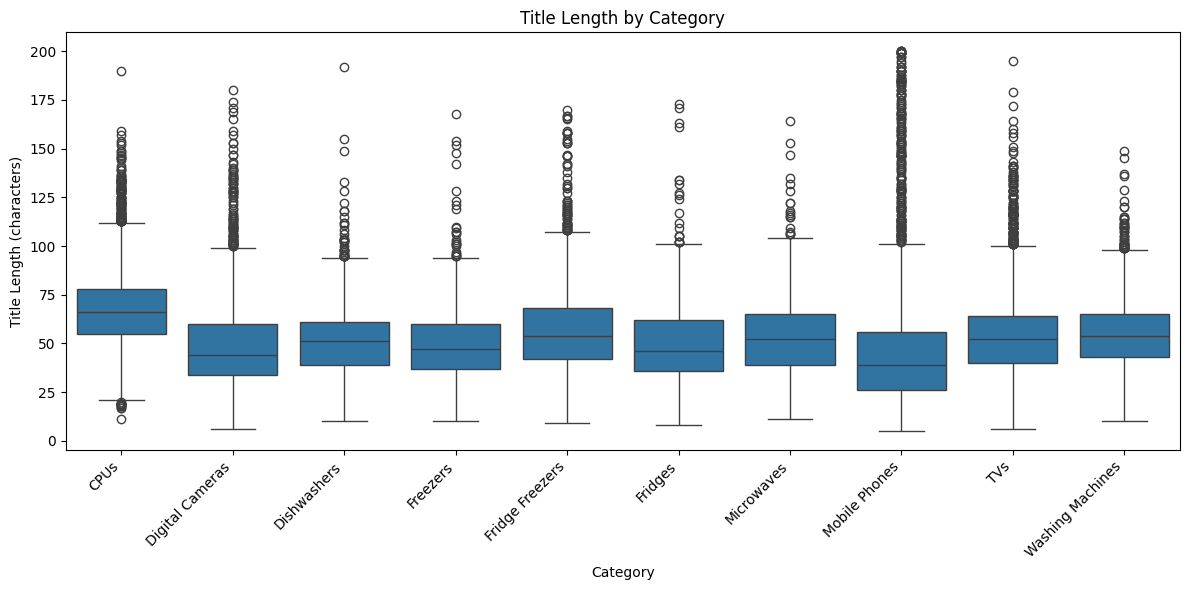

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Category Label", y="title_length")
plt.title("Title Length by Category")
plt.xlabel("Category")
plt.ylabel("Title Length (characters)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.6. Uklanjanje kolona koje nisu korisne za model

Kolone `product ID`, `Merchant ID`, `_Product Code` i `Listing Date` su
identifikatori ili metapodaci bez direktne veze sa tekstom naslova i njegovom
kategorijom, pa ih ne koristimo kao ulazne karakteristike za model.

In [52]:
feature_columns = [
    "Product Title",
    "title_length",
    "word_count",
    "has_digit",
    "longest_word_length",
]

X = df[feature_columns]
y = df["Category Label"]

print("Features used for modeling:")
print(X.head())
print("\nTarget variable:")
print(y.head())

Features used for modeling:
                                       Product Title  title_length  \
0                    apple iphone 8 plus 64gb silver            31   
1                apple iphone 8 plus 64 gb spacegrau            35   
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            70   
3                apple iphone 8 plus 64gb space grey            35   
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            54   

   word_count  has_digit  longest_word_length  
0           6          1                    6  
1           7          1                    9  
2          13          1                   10  
3           7          1                    6  
4          11          1                    8  

Target variable:
0    Mobile Phones
1    Mobile Phones
2    Mobile Phones
3    Mobile Phones
4    Mobile Phones
Name: Category Label, dtype: category
Categories (10, object): ['CPUs', 'Digital Cameras', 'Dishwashers', 'Freezers', ...,
                          '

## Zapažanja iz faze inženjeringa karakteristika

- Dodate su četiri nove numeričke karakteristike izvedene iz naslova proizvoda:
  `title_length`, `word_count`, `has_digit`, `longest_word_length`.
- `Number_of_Views` i `Merchant Rating` nisu direktno povezane sa tekstom naslova
  i kategorijom proizvoda pa ih ne koristimo kao ulaz za predikciju kategorije
  na osnovu naslova.
- Zadržani su `Product Title` (glavna karakteristika za TF-IDF vektorizaciju) i
  četiri nove numeričke karakteristike kao konačan skup ulaznih podataka za model.